Import Libraries

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded")

Libraries loaded


Read All 1007 Files and Combine

In [2]:
from typing import final
# Find all .csv.gz files across all year folders
all_files = glob.glob(
    os.path.expanduser('~/Desktop/delhi_okhla_project/raw_data/**/*.csv.gz'),
    recursive=True
)

print(f"Files found: {len(all_files)}")

# Read every file and combine into one big table
all_dfs = []

for i, file in enumerate(all_files):
    try:
        temp = pd.read_csv(file, compression='gzip')
        all_dfs.append(temp)
    except Exception as e:
        print(f"Skipped: {file} — {e}")

# Combine everything
raw_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal rows: {raw_df.shape[0]:,}")
print(f"Total columns: {raw_df.shape[1]}")
print(f"\nColumn names:\n{raw_df.columns.tolist()}")

Files found: 1007

Total rows: 396,286
Total columns: 9

Column names:
['location_id', 'sensors_id', 'location', 'datetime', 'lat', 'lon', 'parameter', 'units', 'value']


Understand What We Have

In [3]:
# First look at the raw data
print("First 5 rows:")
print(raw_df.head())

print("\nData types:")
print(raw_df.dtypes)

print("\nUnique parameters/pollutants in this data:")
print(raw_df['parameter'].unique())

First 5 rows:
   location_id  sensors_id                          location  \
0         8239       24011  Okhla Phase-2, Delhi - DPCC-8239   
1         8239       24011  Okhla Phase-2, Delhi - DPCC-8239   
2         8239       24011  Okhla Phase-2, Delhi - DPCC-8239   
3         8239       24011  Okhla Phase-2, Delhi - DPCC-8239   
4         8239       24011  Okhla Phase-2, Delhi - DPCC-8239   

                    datetime        lat        lon parameter  units  value  
0  2022-03-28T00:15:00+05:30  28.530785  77.271255      pm10  µg/m³  471.0  
1  2022-03-28T01:00:00+05:30  28.530785  77.271255      pm10  µg/m³  385.0  
2  2022-03-28T02:15:00+05:30  28.530785  77.271255      pm10  µg/m³  416.0  
3  2022-03-28T03:15:00+05:30  28.530785  77.271255      pm10  µg/m³  371.0  
4  2022-03-28T04:15:00+05:30  28.530785  77.271255      pm10  µg/m³  282.0  

Data types:
location_id      int64
sensors_id       int64
location           str
datetime           str
lat            float64
lon        

Clean and Reshape the Data

In [4]:
# Step 1: Keep only the columns we need
df = raw_df[['datetime', 'parameter', 'value']].copy()

# Step 2: Convert datetime column to actual datetime objects
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)

# Convert UTC to India Standard Time (IST = UTC + 5:30)
df['datetime'] = df['datetime'].dt.tz_convert('Asia/Kolkata')

# Extract just the date (without time) for daily aggregation
df['date'] = df['datetime'].dt.date

# Step 3: Remove obviously wrong values
# Negative pollution readings are sensor errors
# Values above 2000 are almost certainly errors too
df = df[(df['value'] >= 0) & (df['value'] <= 2000)]

# Step 4: Calculate daily average for each pollutant
# Group by date + pollutant, take the mean of all hourly readings that day
daily_df = df.groupby(['date', 'parameter'])['value'].mean().reset_index()
# reset_index() converts the groupby result back into a regular flat table

print("Daily aggregated data:")
print(daily_df.head(10))
print(f"\nShape: {daily_df.shape}")

Daily aggregated data:
         date parameter        value
0  2020-01-01        co  1248.888889
1  2020-01-01       no2    51.054167
2  2020-01-01        o3    84.718056
3  2020-01-01      pm10   571.708333
4  2020-01-01      pm25   434.253521
5  2020-01-01       so2    19.690000
6  2020-01-02        co  1013.750000
7  2020-01-02       no2    55.841558
8  2020-01-02        o3    28.797468
9  2020-01-02      pm10   512.387500

Shape: (7478, 3)


Pivot to Wide Format (One Column Per Pollutant)

In [5]:
# Currently data looks like this (LONG format):
# date       | parameter | value
# 2020-01-01 | pm25      | 245.3
# 2020-01-01 | pm10      | 312.1
# 2020-01-01 | no2       | 88.4

# We want this (WIDE format — one row per day):
# date       | pm25  | pm10  | no2  | so2  | co   | o3
# 2020-01-01 | 245.3 | 312.1 | 88.4 | 22.1 | 3.4  | 18.2

final_df = daily_df.pivot_table(
    index='date',
    columns='parameter',
    values='value',
    aggfunc='mean'
).reset_index()

# Clean up column names
final_df.columns.name = None
final_df.columns = [str(c) for c in final_df.columns]

print("Final wide-format data:")
print(final_df.head())
print(f"\nShape: {final_df.shape}")
print(f"\nColumns: {final_df.columns.tolist()}")

Final wide-format data:
         date           co  no        no2  nox         o3        pm10  \
0  2020-01-01  1248.888889 NaN  51.054167  NaN  84.718056  571.708333   
1  2020-01-02  1013.750000 NaN  55.841558  NaN  28.797468  512.387500   
2  2020-01-03   934.615385 NaN  53.137975  NaN  16.741026  367.914634   
3  2020-01-04  1500.000000 NaN  70.468235  NaN  15.108333  332.786517   
4  2020-01-05  1531.250000 NaN  60.221951  NaN  16.810976  252.647059   

         pm25  relativehumidity        so2  temperature  wind_direction  \
0  434.253521               NaN  19.690000          NaN             NaN   
1  362.625000               NaN  22.108108          NaN             NaN   
2  244.707317               NaN  18.914286          NaN             NaN   
3  219.606742               NaN  15.906098          NaN             NaN   
4  173.058824               NaN  15.662821          NaN             NaN   

   wind_speed  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4     

Add Date Features and Save

In [6]:
# Convert date column to datetime for feature extraction
final_df['date'] = pd.to_datetime(final_df['date'])

# Extract useful features the model can learn from
final_df['month'] = final_df['date'].dt.month
# Month is VERY important — Delhi AQI in November ≠ Delhi AQI in July

final_df['year'] = final_df['date'].dt.year

final_df['day_of_year'] = final_df['date'].dt.dayofyear
# Day 1 = Jan 1, Day 300 = late October (Diwali season)

final_df['is_winter'] = final_df['month'].isin([10, 11, 12, 1, 2]).astype(int)
# 1 if October-February (high pollution season), 0 otherwise

# Check for missing values
print("Missing values per column:")
print(final_df.isnull().sum())

print(f"\nDate range: {final_df['date'].min()} to {final_df['date'].max()}")
print(f"Total days: {len(final_df)}")

# Save the clean dataset
final_df.to_csv('delhi_newdelhi_2020_2026_clean.csv', index=False)
print("\n Saved! File: delhi_newdelhi_2020_2026_clean.csv")

Missing values per column:
date                  0
co                   23
no                  649
no2                   3
nox                 877
o3                   10
pm10                  7
pm25                  0
relativehumidity    647
so2                   1
temperature         647
wind_direction      877
wind_speed          877
month                 0
year                  0
day_of_year           0
is_winter             0
dtype: int64

Date range: 2020-01-01 00:00:00 to 2026-02-24 00:00:00
Total days: 1008

 Saved! File: delhi_newdelhi_2020_2026_clean.csv


All Pollutants Available

In [7]:
print(final_df.describe())

                      date           co          no          no2         nox  \
count                 1008   985.000000  359.000000  1005.000000  131.000000   
mean   2022-10-08 14:51:25   663.477115   38.902101    55.831861    0.117089   
min    2020-01-01 00:00:00     0.000000    1.205970     0.157778    0.036240   
25%    2020-09-22 18:00:00     1.850114    7.735337    28.714286    0.074358   
50%    2021-12-14 12:00:00   760.000000   19.759375    48.023256    0.099552   
75%    2025-06-08 06:00:00  1143.023256   49.303333    75.513043    0.161222   
max    2026-02-24 00:00:00  2000.000000  348.753750   219.128947    0.369679   
std                    NaN   573.662737   49.766870    34.350677    0.062112   

               o3         pm10         pm25  relativehumidity          so2  \
count  998.000000  1001.000000  1008.000000        361.000000  1007.000000   
mean    37.171871   212.456311    98.622905         64.123148    12.615898   
min      0.000000    10.583333     3.000000  

Quick Look at What We Have


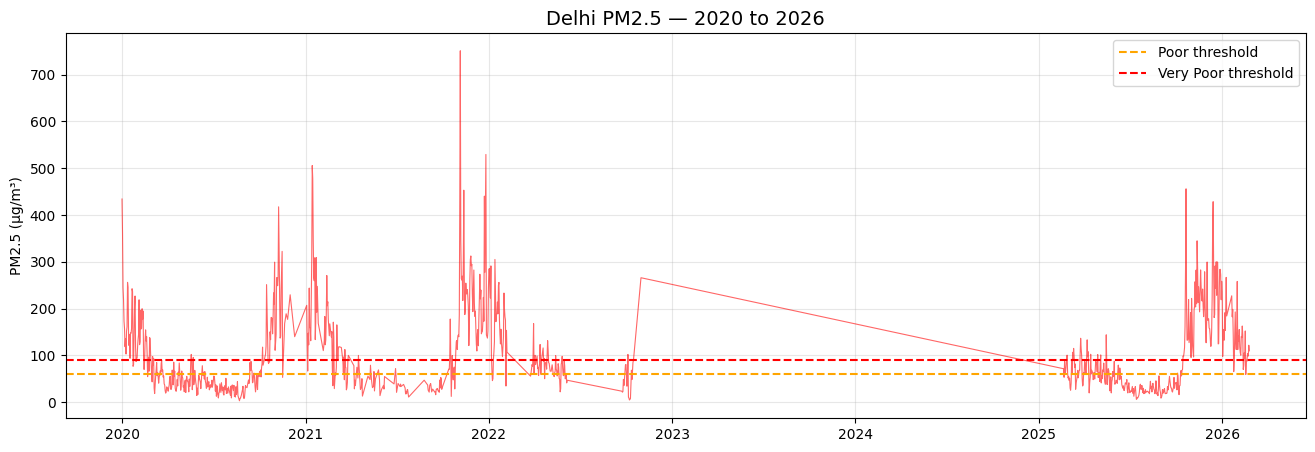

In [8]:
# Plot PM2.5 over 6 years
plt.figure(figsize=(16, 5))
plt.plot(final_df['date'], final_df['pm25'], color='red', alpha=0.6, linewidth=0.8)
plt.title('Delhi PM2.5 — 2020 to 2026', fontsize=14)
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=60, color='orange', linestyle='--', label='Poor threshold')
plt.axhline(y=90, color='red', linestyle='--', label='Very Poor threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Select and Clean Features

In [9]:
# Columns we're KEEPING as features
# Dropped: no, nox, relativehumidity, temperature, wind_direction, wind_speed
# Reason: 60-87% missing — not usable for training
# We predict PM2.5 directly — it's the single biggest driver of Delhi's AQI
# PM2.5 alone determines whether AQI is Good / Poor / Severe

features_to_use = ['co', 'no2', 'o3', 'pm10', 'so2', 'month', 'year', 'day_of_year', 'is_winter']

target = 'pm25'

# clean copy of the data
model_df = final_df[features_to_use + [target, 'date']].copy()

# Fill the 23 missing CO values with median
# Median is better than mean because CO has extreme outliers 
model_df['co'] = model_df['co'].fillna(model_df['co'].median())

# Fill remaining small gaps with median too
for col in ['no2', 'o3', 'pm10', 'so2']:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print("Missing values after cleaning:")
print(model_df.isnull().sum())
print(f"\nFinal shape: {model_df.shape}")

Missing values after cleaning:
co             0
no2            0
o3             0
pm10           0
so2            0
month          0
year           0
day_of_year    0
is_winter      0
pm25           0
date           0
dtype: int64

Final shape: (1008, 11)


Visualise Before Training

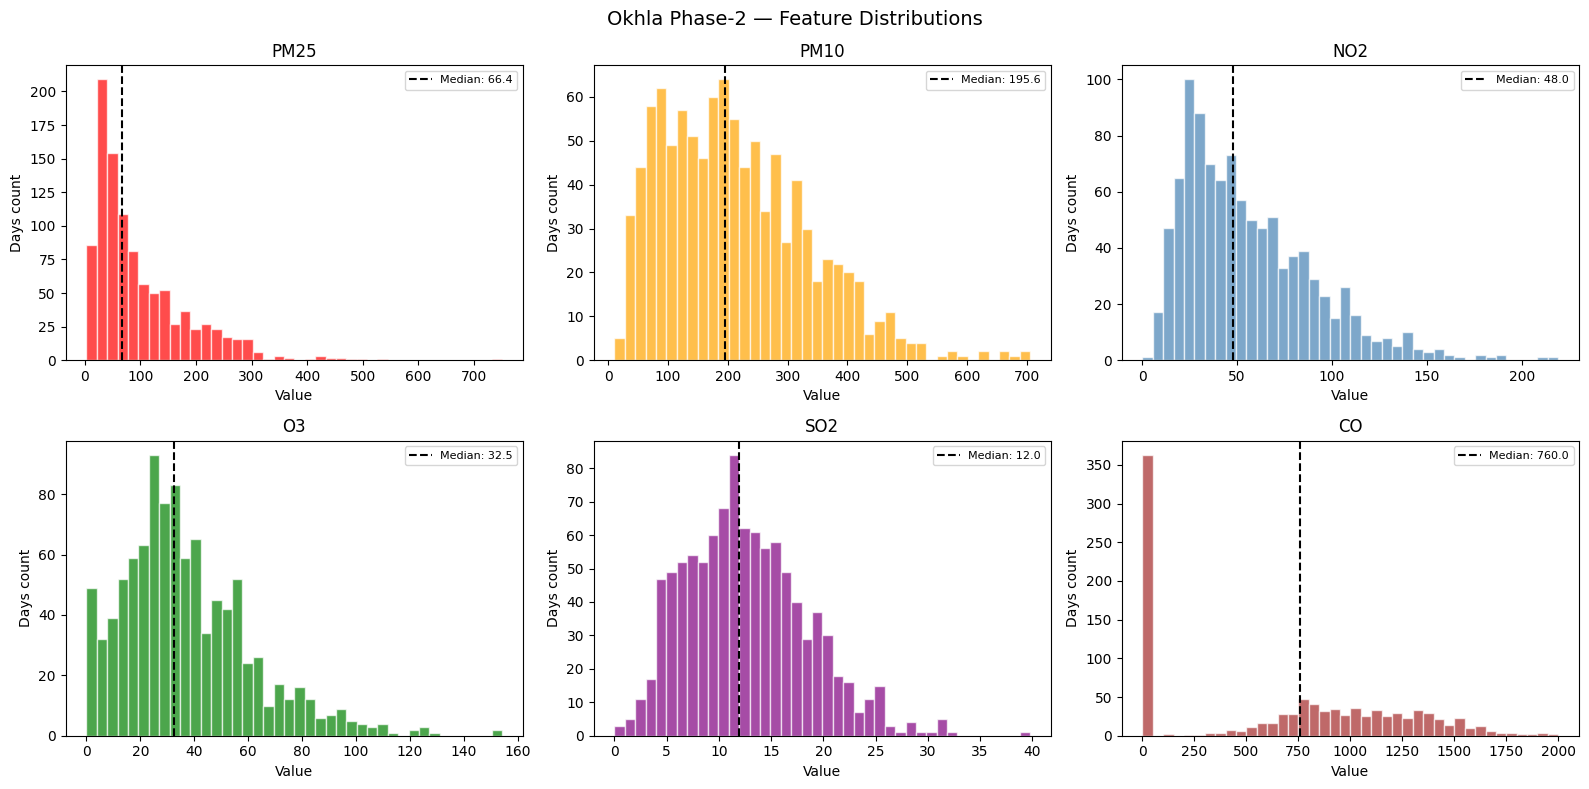

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Okhla Phase-2 — Feature Distributions', fontsize=14)

cols_to_plot = ['pm25', 'pm10', 'no2', 'o3', 'so2', 'co']
colors = ['red', 'orange', 'steelblue', 'green', 'purple', 'brown']

for ax, col, color in zip(axes.flatten(), cols_to_plot, colors):
    ax.hist(model_df[col], bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(col.upper())
    ax.set_xlabel('Value')
    ax.set_ylabel('Days count')
    ax.axvline(model_df[col].median(), color='black',
               linestyle='--', linewidth=1.5, label=f'Median: {model_df[col].median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Correlation Heatmap

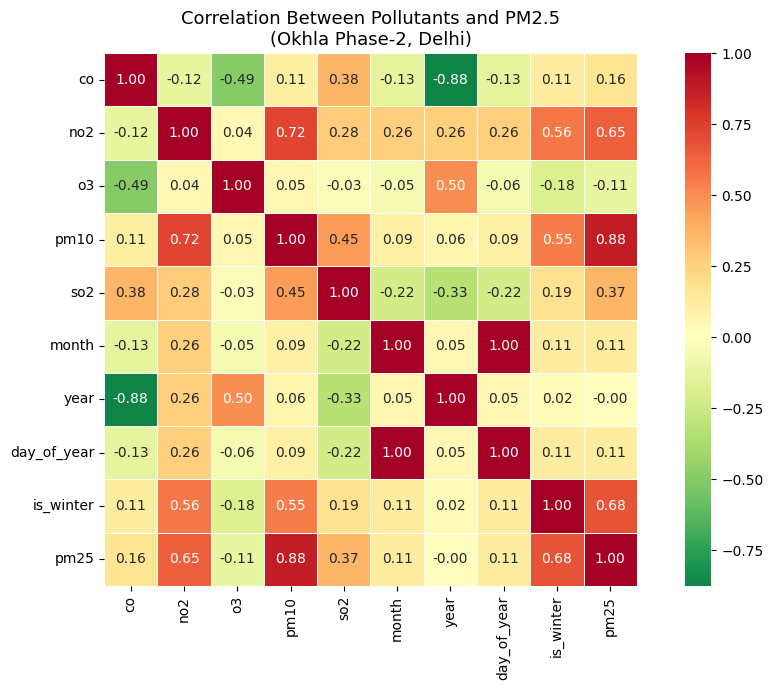

In [11]:
#Which Pollutant Affects PM2.5 Most?

plt.figure(figsize=(10, 7))

corr = model_df[features_to_use + ['pm25']].corr()

sns.heatmap(
    corr,
    annot=True,           # show numbers inside cells
    fmt='.2f',            # 2 decimal places
    cmap='RdYlGn_r',      # red = high correlation, green = low
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Between Pollutants and PM2.5\n(Okhla Phase-2, Delhi)', fontsize=13)
plt.tight_layout()
plt.show()

PM2.5 by Month

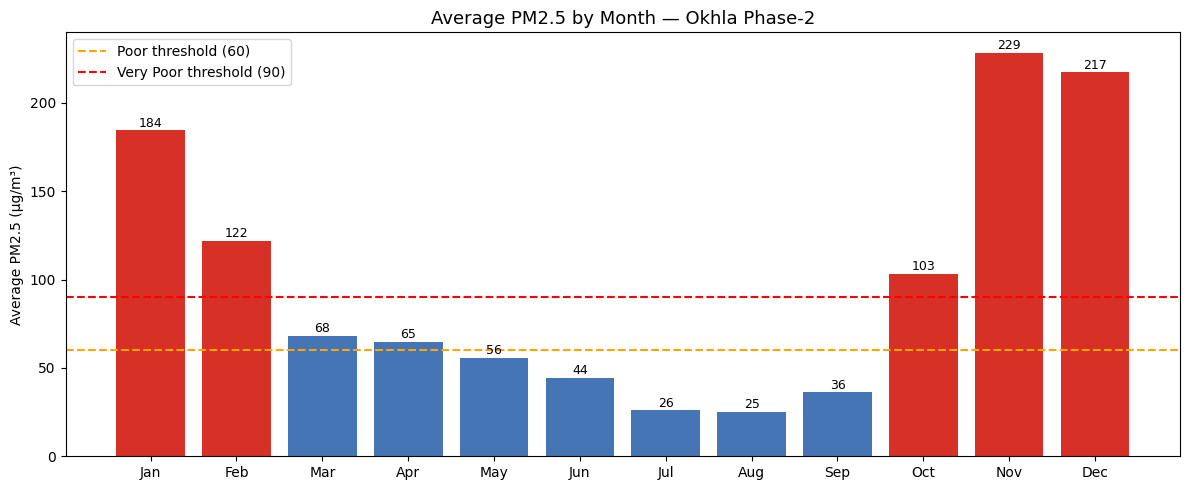

In [12]:
#Seasonal Pattern
monthly = model_df.groupby('month')['pm25'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
bars = plt.bar(range(1, 13), monthly.values,
               color=['#d73027' if m in [10,11,12,1,2] else '#4575b4'
                      for m in range(1, 13)])

plt.xticks(range(1, 13), month_names)
plt.title('Average PM2.5 by Month — Okhla Phase-2', fontsize=13)
plt.ylabel('Average PM2.5 (µg/m³)')
plt.axhline(y=60, color='orange', linestyle='--', label='Poor threshold (60)')
plt.axhline(y=90, color='red', linestyle='--', label='Very Poor threshold (90)')
plt.legend()

# Add value labels on top of each bar
for i, v in enumerate(monthly.values):
    plt.text(i + 1, v + 2, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Split Data Into Train and Test

In [13]:
from sklearn.model_selection import train_test_split
X = model_df[features_to_use]   # inputs — all pollutant + time columns
y = model_df[target]            # output — PM2.5 value we want to predict

# 80% training, 20% testing
# random_state=42 means same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")   # model learns from these
print(f"Testing rows:  {len(X_test)}")    # model never sees these during training
print(f"\nFeatures used: {features_to_use}")

Training rows: 806
Testing rows:  202

Features used: ['co', 'no2', 'o3', 'pm10', 'so2', 'month', 'year', 'day_of_year', 'is_winter']


Train the Model

In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,    # 200 decision trees — they vote together for final answer
    max_depth=15,        # each tree can ask at most 15 questions before deciding
    min_samples_leaf=3,  # each final decision must be based on at least 3 days
                         # prevents model from memorising single days (overfitting)
    random_state=42,
    n_jobs=-1            # use all CPU cores on our machine — trains faster
)

print("Training started...")
model.fit(X_train, y_train)
# The model reads 806 rows of Delhi pollution data and learns patterns like:
# "When pm10 > 300 AND month is November → pm25 is probably above 200"
# "When o3 is high AND month is July → pm25 is probably low (monsoon)"

print("Training complete!")

Training started...
Training complete!


Evaluate the Model

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=" * 40)
print(f"  Mean Absolute Error : {mae:.2f} µg/m³")
print(f"  R² Score            : {r2:.4f}")
print(f"  Model explains      : {r2*100:.1f}% of PM2.5 variation")
print("=" * 40)

  Mean Absolute Error : 12.41 µg/m³
  R² Score            : 0.9501
  Model explains      : 95.0% of PM2.5 variation


Actual vs Predicted Plot

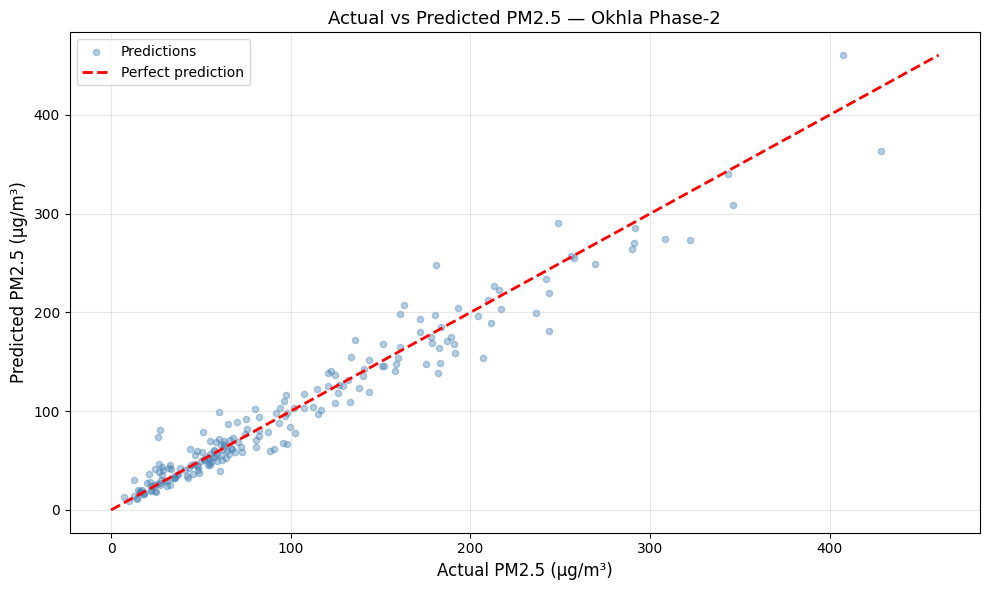

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20, label='Predictions')

max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual PM2.5 (µg/m³)', fontsize=12)
plt.ylabel('Predicted PM2.5 (µg/m³)', fontsize=12)
plt.title('Actual vs Predicted PM2.5 — Okhla Phase-2', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance

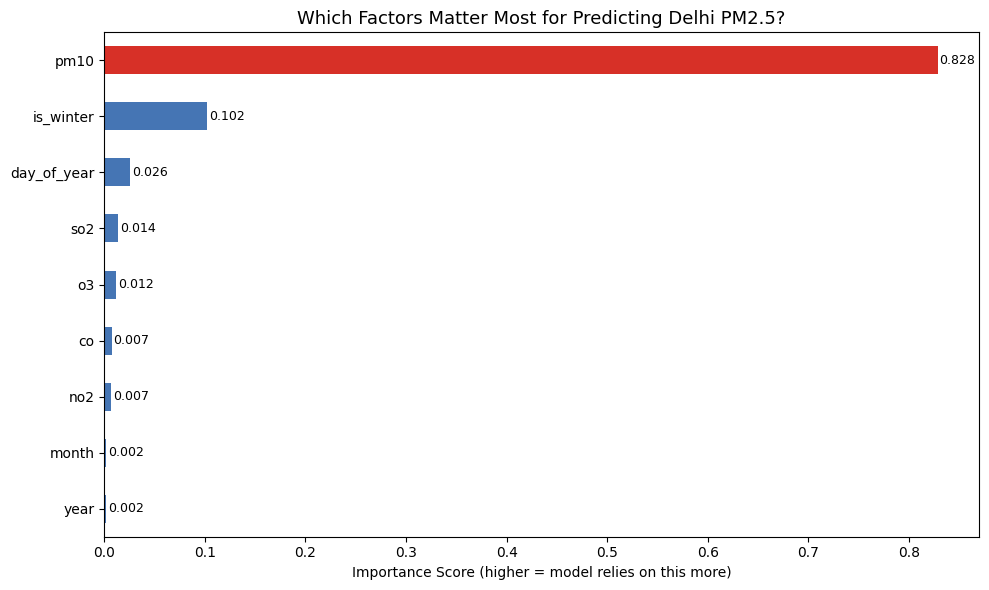

In [17]:
#What Did the Model Learn?

importance = pd.Series(
    model.feature_importances_,
    index=features_to_use
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#d73027' if imp > 0.15 else '#4575b4' for imp in importance.values]
importance.plot(kind='barh', color=colors)

plt.title('Which Factors Matter Most for Predicting Delhi PM2.5?', fontsize=13)
plt.xlabel('Importance Score (higher = model relies on this more)')

for i, v in enumerate(importance.values):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Prediction for Okhla

In [18]:
import pandas as pd
# Values based on what our data showed for Nov-Dec period
winter_day = pd.DataFrame([{
    'co':          900,    # high — typical Delhi winter CO
    'no2':         95,     # high — heavy traffic
    'o3':          18,     # low — ozone drops in winter
    'pm10':        350,    # very high — dust + vehicles
    'so2':         20,     # moderate
    'month':       11,     # November — worst month
    'year':        2025,
    'day_of_year': 315,    # ~November 11
    'is_winter':   1       # yes, it's winter
}])

predicted_pm25 = model.predict(winter_day)[0]

print(f"Predicted PM2.5: {predicted_pm25:.1f} µg/m³")

# Convert to AQI category
if predicted_pm25 <= 30:
    cat, advice = "Good 🟢", "Safe to go outside!"
elif predicted_pm25 <= 60:
    cat, advice = "Satisfactory 🟡", "Sensitive people should be cautious"
elif predicted_pm25 <= 90:
    cat, advice = "Moderate 🟠", "Limit prolonged outdoor activity"
elif predicted_pm25 <= 120:
    cat, advice = "Poor 🔴", "Wear N95 mask outside"
elif predicted_pm25 <= 250:
    cat, advice = "Very Poor 🟣", "Avoid going outside"
else:
    cat, advice = "Severe ☠️", "Stay indoors, seal windows"

print(f"Category : {cat}")
print(f"Advice   : {advice}")

# Now try a clean monsoon day
monsoon_day = pd.DataFrame([{
    'co':          200,
    'no2':         25,
    'o3':          55,
    'pm10':        80,
    'so2':         8,
    'month':       8,      # August — monsoon
    'year':        2025,
    'day_of_year': 220,
    'is_winter':   0
}])

predicted_monsoon = model.predict(monsoon_day)[0]
print(f"\nMonsoon day PM2.5: {predicted_monsoon:.1f} µg/m³")

Predicted PM2.5: 201.7 µg/m³
Category : Very Poor 🟣
Advice   : Avoid going outside

Monsoon day PM2.5: 26.1 µg/m³


The Big Conceptual Shift Why This is Different
What we built before:

"Given PM10, NO2, CO readings RIGHT NOW → what is PM2.5 RIGHT NOW?"

What we're building now:

"Given everything I know TODAY → what will PM2.5 be TOMORROW?"

This is called Time Series Forecasting and it has one rule that changes everything:

In our previous model we split data randomly any day could go into training or testing. That's fine when predicting the present.
For predicting the future we cannot do this. We can never train on future data and test on past data. That's cheating in real life we don't know the future.

lag features: The way we teach a model to predict tomorrow is by giving it yesterday's information as input columns. 

The model learns: when PM2.5 has been rising for 3 days in November → it will probably rise again tomorrow.

Build Lag Features

In [19]:
#we will use our clean saved file
# This keeps our previous model untouched
ts_df = pd.read_csv('delhi_newdelhi_2020_2026_clean.csv')
ts_df['date'] = pd.to_datetime(ts_df['date'])

# Sort by date, critical for time series
# Data must be in chronological order before creating lag features
ts_df = ts_df.sort_values('date').reset_index(drop=True)

# ── CREATE LAG FEATURES ──────────────────────────────────────────
# So row for 2024-11-02 gets the PM2.5 value from 2024-11-01 → "yesterday's PM2.5"
# This is how we give the model historical information

ts_df['pm25_lag1'] = ts_df['pm25'].shift(1)   # yesterday
ts_df['pm25_lag2'] = ts_df['pm25'].shift(2)   # 2 days ago
ts_df['pm25_lag3'] = ts_df['pm25'].shift(3)   # 3 days ago
ts_df['pm25_lag7'] = ts_df['pm25'].shift(7)   # same day last week

# Same for PM10 
ts_df['pm10_lag1'] = ts_df['pm10'].shift(1)
ts_df['pm10_lag2'] = ts_df['pm10'].shift(2)

# And NO2
ts_df['no2_lag1'] = ts_df['no2'].shift(1)
ts_df['no2_lag2'] = ts_df['no2'].shift(2)

# ── ROLLING AVERAGES ─────────────────────────────────────────────
# A 7-day rolling average smooths out daily noise
# and captures the "trend" is air quality getting better or worse?
# min_periods=1 means calculate even if fewer than 7 days are available

ts_df['pm25_rolling7']  = ts_df['pm25'].shift(1).rolling(window=7,  min_periods=1).mean()
ts_df['pm25_rolling14'] = ts_df['pm25'].shift(1).rolling(window=14, min_periods=1).mean()
# Note: we .shift(1) BEFORE rolling so we only use past data, never today's

# ── TOMORROW'S PM2.5 = OUR TARGET ────────────────────────────────
# .shift(-1) moves column UP by 1 so today's row gets tomorrow's value
# This is what we want to predict
ts_df['pm25_tomorrow'] = ts_df['pm25'].shift(-1)

print("Lag features created")
print(f"\nShape: {ts_df.shape}")
print(ts_df[['date','pm25','pm25_lag1','pm25_lag2','pm25_lag7','pm25_tomorrow']].head(10))

Lag features created

Shape: (1008, 28)
        date        pm25   pm25_lag1   pm25_lag2   pm25_lag7  pm25_tomorrow
0 2020-01-01  434.253521         NaN         NaN         NaN     362.625000
1 2020-01-02  362.625000  434.253521         NaN         NaN     244.707317
2 2020-01-03  244.707317  362.625000  434.253521         NaN     219.606742
3 2020-01-04  219.606742  244.707317  362.625000         NaN     173.058824
4 2020-01-05  173.058824  219.606742  244.707317         NaN     157.303797
5 2020-01-06  157.303797  173.058824  219.606742         NaN     118.580247
6 2020-01-07  118.580247  157.303797  173.058824         NaN     135.348315
7 2020-01-08  135.348315  118.580247  157.303797  434.253521     102.905882
8 2020-01-09  102.905882  135.348315  118.580247  362.625000     151.731707
9 2020-01-10  151.731707  102.905882  135.348315  244.707317     161.011905


Drop NaN Rows and Select Features

In [20]:
# Drop rows where any lag feature or target is NaN
# First 7 rows → no lag7 available
# Last 1 row  → no tomorrow value available
ts_df = ts_df.dropna(subset=[
    'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag7',
    'pm25_rolling7', 'pm25_rolling14',
    'pm25_tomorrow'
]).reset_index(drop=True)

# Features the model uses to predict tomorrow
time_features = [
    'pm25_lag1',        # yesterday's PM2.5
    'pm25_lag2',        # 2 days ago
    'pm25_lag3',        # 3 days ago
    'pm25_lag7',        # same day last week
    'pm10_lag1',        # yesterday's PM10
    'pm10_lag2',
    'no2_lag1',         # yesterday's NO2
    'no2_lag2',
    'pm25_rolling7',    # 7-day average trend
    'pm25_rolling14',   # 14-day average trend
    'month',            # what month is today
    'day_of_year',      # where in the year are we
    'is_winter',        # is it high-pollution season
]

X = ts_df[time_features]
y = ts_df['pm25_tomorrow']   # what we want to predict

print(f"Total usable days: {len(X)}")
print(f"\nFeatures: {time_features}")

Total usable days: 1000

Features: ['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag7', 'pm10_lag1', 'pm10_lag2', 'no2_lag1', 'no2_lag2', 'pm25_rolling7', 'pm25_rolling14', 'month', 'day_of_year', 'is_winter']


Chronological Train/Test Split 

In [21]:
# The model will train on 2020-2024
# and be tested on 2025-2026 data it has NEVER seen

# Find where 2025 starts in our data
split_date = '2025-01-01'
split_idx = ts_df[ts_df['date'] >= split_date].index[0]

# Everything BEFORE 2025 = training
X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

# Everything FROM 2025 onwards = testing
X_test  = X.iloc[split_idx:]
y_test  = y.iloc[split_idx:]
test_dates = ts_df['date'].iloc[split_idx:]

print(f"Training: {ts_df['date'].iloc[0].date()} → {ts_df['date'].iloc[split_idx-1].date()}")
print(f"Testing:  {ts_df['date'].iloc[split_idx].date()} → {ts_df['date'].iloc[-1].date()}")
print(f"\nTraining days: {len(X_train)}")
print(f"Testing days:  {len(X_test)}")

Training: 2020-01-08 → 2022-10-31
Testing:  2025-02-19 → 2026-02-23

Training days: 640
Testing days:  360


Fill NaN Before Training

In [23]:
# Check exactly which columns still have NaN
print("NaN values in X_train:")
print(X_train.isnull().sum())

# Fill NaN in ALL feature columns with their median
for col in time_features:
    median_val = X_train[col].median()
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col]  = X_test[col].fillna(median_val)
    # we use TRAINING median to fill test data too
    # Never calculate statistics from test data that's data leakage

print("\nNaN values after filling:")
print(X_train.isnull().sum())
print("\nAll zeros = ready to train")

NaN values in X_train:
pm25_lag1         0
pm25_lag2         0
pm25_lag3         0
pm25_lag7         0
pm10_lag1         7
pm10_lag2         7
no2_lag1          1
no2_lag2          1
pm25_rolling7     0
pm25_rolling14    0
month             0
day_of_year       0
is_winter         0
dtype: int64

NaN values after filling:
pm25_lag1         0
pm25_lag2         0
pm25_lag3         0
pm25_lag7         0
pm10_lag1         0
pm10_lag2         0
no2_lag1          0
no2_lag2          0
pm25_rolling7     0
pm25_rolling14    0
month             0
day_of_year       0
is_winter         0
dtype: int64

All zeros = ready to train


Train the Time Series Model

In [24]:
from sklearn.ensemble import GradientBoostingRegressor
# We're switching from Random Forest to Gradient Boosting here
# Gradient Boosting learns sequentially each tree fixes the mistakes of the previous one
# It's generally better for time series because it handles trends well

model_ts = GradientBoostingRegressor(
    n_estimators=300,      # 300 trees built sequentially
    learning_rate=0.05,    # each tree contributes a small amount more careful learning
    max_depth=5,           # shallower trees prevents overfitting on time patterns
    min_samples_leaf=5,    # each decision based on at least 5 days
    random_state=42
)

print("Training time series model...")
model_ts.fit(X_train, y_train)
print("Training complete!")

Training time series model...
Training complete!


Evaluate

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_ts = model_ts.predict(X_test)

mae_ts = mean_absolute_error(y_test, y_pred_ts)
r2_ts  = r2_score(y_test, y_pred_ts)

print("=" * 45)
print(f"  Mean Absolute Error : {mae_ts:.2f} µg/m³")
print(f"  R² Score            : {r2_ts:.4f}")
print(f"  Model explains      : {r2_ts*100:.1f}% of tomorrow's PM2.5 variation")
print("=" * 45)

  Mean Absolute Error : 29.10 µg/m³
  R² Score            : 0.6764
  Model explains      : 67.6% of tomorrow's PM2.5 variation


Plot Predicted vs Actual Over Time

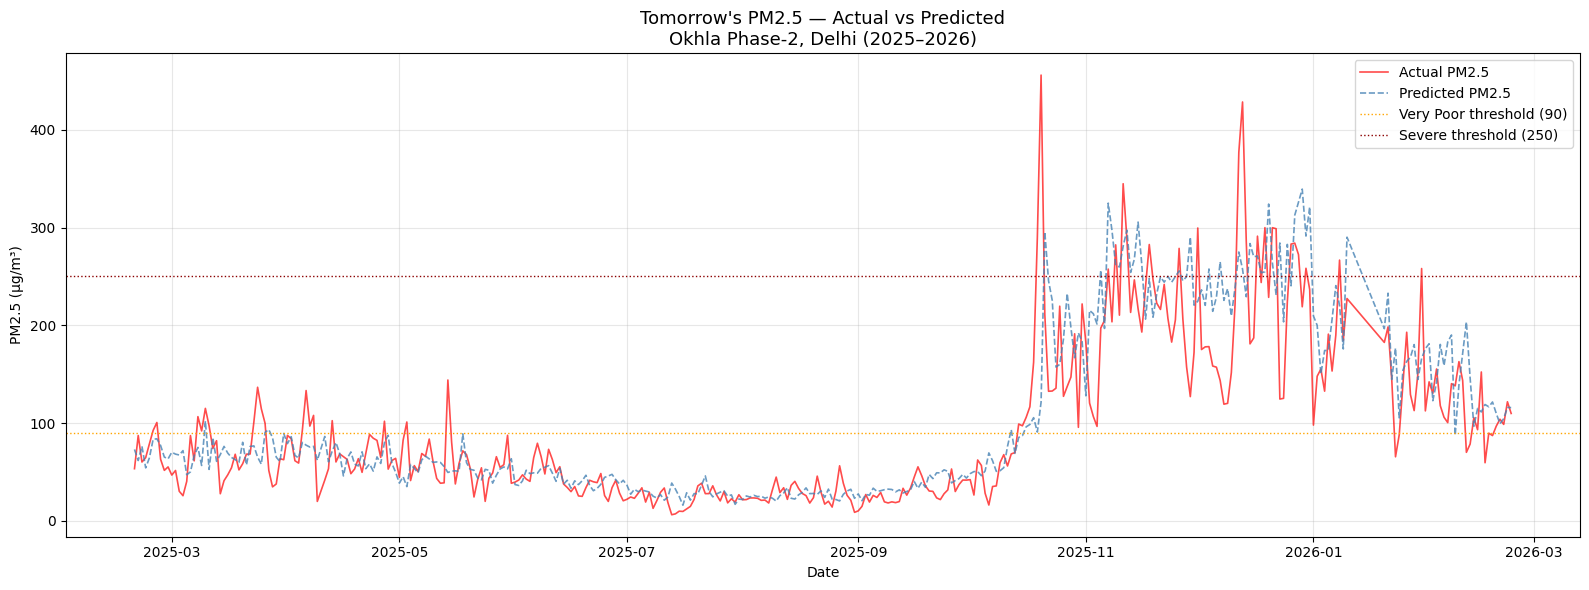

In [26]:
plt.figure(figsize=(16, 6))

plt.plot(test_dates.values, y_test.values,
         color='red', alpha=0.7, linewidth=1.2, label='Actual PM2.5')

plt.plot(test_dates.values, y_pred_ts,
         color='steelblue', alpha=0.8, linewidth=1.2,
         linestyle='--', label='Predicted PM2.5')

plt.axhline(y=90,  color='orange', linestyle=':', linewidth=1, label='Very Poor threshold (90)')
plt.axhline(y=250, color='darkred', linestyle=':', linewidth=1, label='Severe threshold (250)')

plt.title("Tomorrow's PM2.5 — Actual vs Predicted\nOkhla Phase-2, Delhi (2025–2026)", fontsize=13)
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Date')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance for Time Series

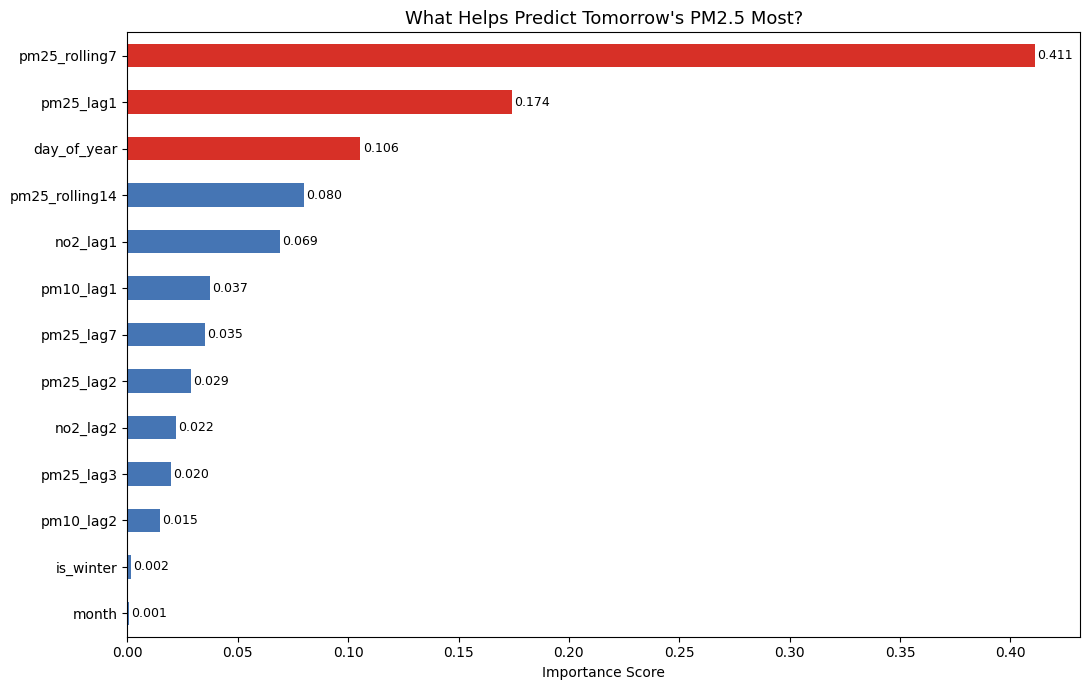

In [27]:
importance_ts = pd.Series(
    model_ts.feature_importances_,
    index=time_features
).sort_values(ascending=True)

plt.figure(figsize=(11, 7))
colors = ['#d73027' if imp > 0.10 else '#4575b4' for imp in importance_ts.values]
importance_ts.plot(kind='barh', color=colors)

plt.title("What Helps Predict Tomorrow's PM2.5 Most?", fontsize=13)
plt.xlabel('Importance Score')

for i, v in enumerate(importance_ts.values):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Predict Tomorrow for Real

In [29]:
#Today = Feb 28, 2026

#This simulates what the model would say TODAY about TOMORROW

# Safely get last available values
last      = ts_df.iloc[-1]
second    = ts_df.iloc[-2]
third     = ts_df.iloc[-3]
last_week = ts_df.iloc[-7]

last_date    = pd.to_datetime(last['date'])
tomorrow     = last_date + pd.Timedelta(days=1)
tomorrow_month = tomorrow.month
tomorrow_doy   = tomorrow.day_of_year if hasattr(tomorrow, 'day_of_year') else tomorrow.timetuple().tm_yday

# is_winter = True only for Oct, Nov, Dec, Jan, Feb
is_tomorrow_winter = 1 if tomorrow_month in [10, 11, 12, 1, 2] else 0

tomorrow_input = pd.DataFrame([{
    'pm25_lag1':      last['pm25'],
    'pm25_lag2':      second['pm25'],
    'pm25_lag3':      third['pm25'],
    'pm25_lag7':      last_week['pm25'],
    'pm10_lag1':      last['pm10'],
    'pm10_lag2':      second['pm10'],
    'no2_lag1':       last['no2'],
    'no2_lag2':       second['no2'],
    'pm25_rolling7':  ts_df['pm25'].tail(7).mean(),
    'pm25_rolling14': ts_df['pm25'].tail(14).mean(),
    'month':          tomorrow_month,      
    'day_of_year':    tomorrow_doy,        
    'is_winter':      is_tomorrow_winter   
}])

predicted_tomorrow = model_ts.predict(tomorrow_input)[0]

print(f"\nLatest data available : {last_date.date()}")
print(f"Predicting for        : {tomorrow.date()}")
print(f"\nLatest known PM2.5    : {last['pm25']:.1f} µg/m³")
print(f"7-day average PM2.5   : {ts_df['pm25'].tail(7).mean():.1f} µg/m³")
print(f"Predicted PM2.5       : {predicted_tomorrow:.1f} µg/m³")
print(f"Month                 : {tomorrow_month} | is_winter: {is_tomorrow_winter}")

if predicted_tomorrow <= 30:
    cat, advice = "Good 🟢", "Safe to be outside all day"
elif predicted_tomorrow <= 60:
    cat, advice = "Satisfactory 🟡", "Generally safe, sensitive groups be cautious"
elif predicted_tomorrow <= 90:
    cat, advice = "Moderate 🟠", "Limit prolonged outdoor activity"
elif predicted_tomorrow <= 120:
    cat, advice = "Poor 🔴", "Wear N95 mask outside"
elif predicted_tomorrow <= 250:
    cat, advice = "Very Poor 🟣", "Avoid going outside"
else:
    cat, advice = "Severe ☠️", "Stay indoors, seal windows, run air purifier"

print(f"\nCategory : {cat}")
print(f"Advice   : {advice}")


Latest data available : 2026-02-23
Predicting for        : 2026-02-24

Latest known PM2.5    : 121.7 µg/m³
7-day average PM2.5   : 93.9 µg/m³
Predicted PM2.5       : 98.1 µg/m³
Month                 : 2 | is_winter: 1

Category : Poor 🔴
Advice   : Wear N95 mask outside


In [30]:
# ── CHECK ACTUAL VS PREDICTED FOR FEB 24 ──────────────────────
actual_feb24 = ts_df[ts_df['date'] == '2026-02-24']['pm25'].values

if len(actual_feb24) > 0:
    actual = actual_feb24[0]
    predicted = 98.1  # what our model predicted
    error = abs(actual - predicted)
    
    print(f"Model predicted for Feb 24 : {predicted:.1f} µg/m³")
    print(f"Actual PM2.5 on Feb 24     : {actual:.1f} µg/m³")
    print(f"Error                      : {error:.1f} µg/m³")
    print(f"Percentage error           : {(error/actual)*100:.1f}%")
    
    if error <= 15:
        print("\n🟢 Excellent prediction!")
    elif error <= 30:
        print("\n🟡 Good prediction")
    elif error <= 50:
        print("\n🟠 Acceptable prediction")
    else:
        print("\n🔴 Model was off — let's investigate why")
else:
    print("Feb 24 not found in dataset")

Feb 24 not found in dataset


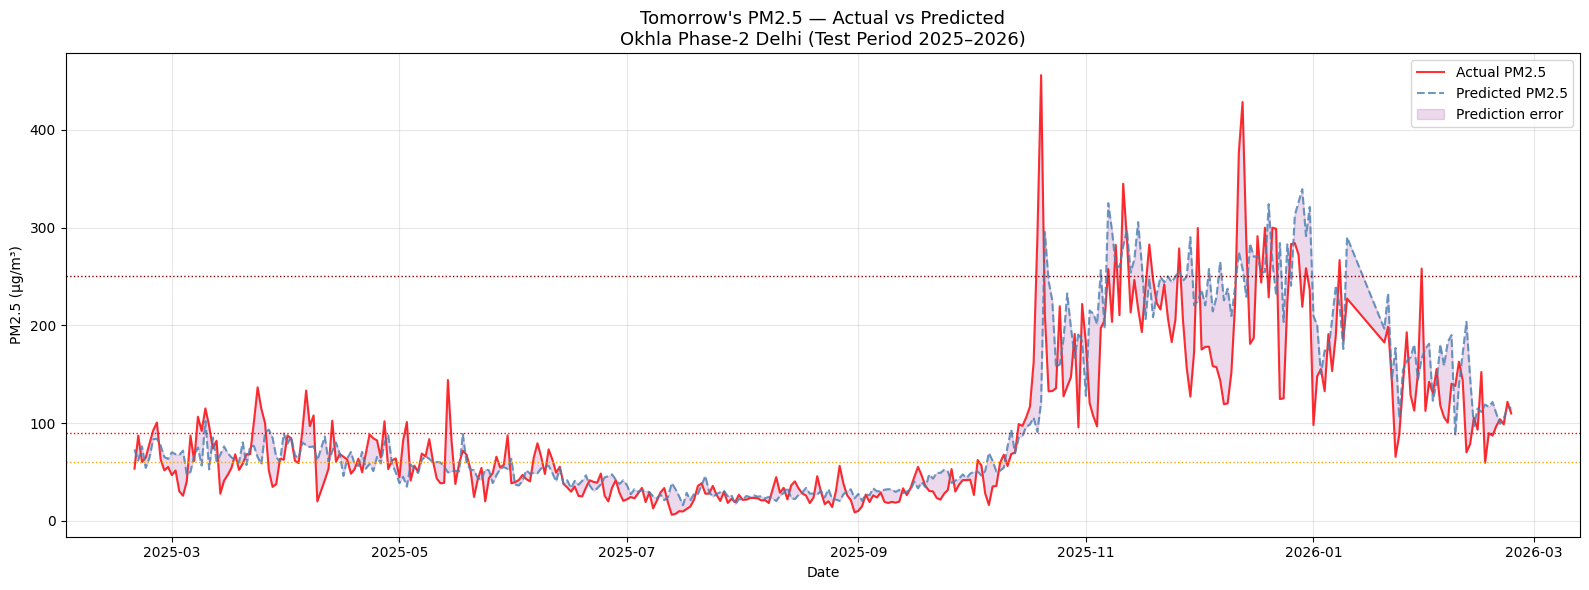

In [31]:
# ── PLOT ACTUAL VS PREDICTED FOR ENTIRE TEST PERIOD ───────────
plt.figure(figsize=(16, 6))

plt.plot(test_dates.values, y_test.values,
         color='red', linewidth=1.5, alpha=0.8, label='Actual PM2.5')

plt.plot(test_dates.values, y_pred_ts,
         color='steelblue', linewidth=1.5,
         linestyle='--', alpha=0.8, label='Predicted PM2.5')

# Shade the error area between actual and predicted
plt.fill_between(test_dates.values, y_test.values, y_pred_ts,
                 alpha=0.15, color='purple', label='Prediction error')

plt.axhline(y=60,  color='orange',  linestyle=':', linewidth=1)
plt.axhline(y=90,  color='red',     linestyle=':', linewidth=1)
plt.axhline(y=250, color='darkred', linestyle=':', linewidth=1)

plt.title("Tomorrow's PM2.5 — Actual vs Predicted\nOkhla Phase-2 Delhi (Test Period 2025–2026)",
          fontsize=13)
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
#  SECTION 2 — MODEL IMPROVEMENT (XGBoost + Tuning)
#  Goal: Beat R² 0.95 from Random Forest baseline
# ═══════════════════════════════════════════════════════

Step 1 → XGBoost       (different, more powerful algorithm)

Step 2 → Cross Validation  (way to measure accuracy)

Step 3 → Hyperparameter Tuning  (finding the best model settings)

In [34]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


Reload Our Clean Data

In [35]:
# We will start with our saved clean file

final_df = pd.read_csv('delhi_newdelhi_2020_2026_clean.csv')
final_df['date'] = pd.to_datetime(final_df['date'])
final_df = final_df.sort_values('date').reset_index(drop=True)

# Recreate the same features from before
features_to_use = ['co', 'no2', 'o3', 'pm10', 'so2',
                   'month', 'year', 'day_of_year', 'is_winter']
target = 'pm25'

model_df = final_df[features_to_use + [target]].copy()

# Fill missing values
for col in features_to_use:
    model_df[col] = model_df[col].fillna(model_df[col].median())

X = model_df[features_to_use]
y = model_df[target]

# Same chronological split as before
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")
print("Data ready")

Training rows : 806
Testing rows  : 202
Data ready


Re-run Our Original Model First

In [36]:
# Re-establish our baseline score to compare against

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print("=" * 45)
print("  BASELINE — Random Forest")
print(f"  MAE : {rf_mae:.2f} µg/m³")
print(f"  R²  : {rf_r2:.4f}")
print("=" * 45)

  BASELINE — Random Forest
  MAE : 12.40 µg/m³
  R²  : 0.9501


XGBoost

Key difference from Random Forest:

Random Forest → builds 200 trees INDEPENDENTLY, takes average

XGBoost       → builds trees SEQUENTIALLY, each one fixing previous mistakes

In [37]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,       # number of trees (boosting rounds)
    learning_rate=0.05,     # how much each tree contributes — lower = more careful
    max_depth=6,            # how deep each tree grows
    subsample=0.8,          # each tree sees 80% of data randomly — prevents overfitting
    colsample_bytree=0.8,   # each tree sees 80% of features randomly
    min_child_weight=3,     # minimum data points needed to make a split
    random_state=42,
    n_jobs=-1,
    verbosity=0             # suppress training output
)

print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],   # monitor test performance during training
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_r2   = r2_score(y_test, xgb_pred)

print("=" * 45)
print("  XGBoost Results")
print(f"  MAE : {xgb_mae:.2f} µg/m³")
print(f"  R²  : {xgb_r2:.4f}")
print("=" * 45)

# Compare
mae_improvement = rf_mae - xgb_mae
r2_improvement  = xgb_r2 - rf_r2

print(f"\n  vs Random Forest:")
print(f"  MAE improved by : {mae_improvement:+.2f} µg/m³")
print(f"  R²  improved by : {r2_improvement:+.4f}")
print(f"\n  {'XGBoost is better!' if xgb_r2 > rf_r2 else 'Random Forest still wins'}")

Training XGBoost...
  XGBoost Results
  MAE : 13.18 µg/m³
  R²  : 0.9379

  vs Random Forest:
  MAE improved by : -0.78 µg/m³
  R²  improved by : -0.0122

  Random Forest still wins


Cross Validation 

In [38]:
# Until now we measured accuracy on ONE test set
# Problem: maybe we got lucky with that particular 20% split
#
# Cross Validation fixes this:
# It splits data into 5 parts (folds)
# Trains on 4 parts, tests on 1 part → repeats 5 times
# Each fold gets to be the test set exactly once
# Final score = average of all 5 tests
#
# This gives a much more accuracy estimate

print("Running 5-Fold Cross Validation...")
print("(This tests the model 5 times on different data splits)\n")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
# shuffle=True because our data is chronological 
# we want random splits to test generalization

# Cross validate both models
rf_cv_scores = cross_val_score(
    rf_model, X, y,
    cv=kfold,
    scoring='r2',    # measure R² each time
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(
    xgb_model, X, y,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

print("Random Forest — 5 Fold R² Scores:")
for i, score in enumerate(rf_cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"  Average: {rf_cv_scores.mean():.4f}  (±{rf_cv_scores.std():.4f})")
# ± tells us consistency — small std = model is stable

print("\nXGBoost — 5 Fold R² Scores:")
for i, score in enumerate(xgb_cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"  Average: {xgb_cv_scores.mean():.4f}  (±{xgb_cv_scores.std():.4f})")

print("\n💡 The average cross-val R² is more trustworthy than single test R²")

Running 5-Fold Cross Validation...
(This tests the model 5 times on different data splits)

Random Forest — 5 Fold R² Scores:
  Fold 1: 0.9489
  Fold 2: 0.8627
  Fold 3: 0.9430
  Fold 4: 0.9365
  Fold 5: 0.9533
  Average: 0.9289  (±0.0336)

XGBoost — 5 Fold R² Scores:
  Fold 1: 0.9363
  Fold 2: 0.8814
  Fold 3: 0.9249
  Fold 4: 0.9333
  Fold 5: 0.9147
  Average: 0.9181  (±0.0198)

💡 The average cross-val R² is more trustworthy than single test R²


Hyperparameter Tuning with GridSearchCV

In [39]:
from sklearn.model_selection import GridSearchCV

# Hyperparameters = the settings we choose BEFORE training
# (like n_estimators=300, max_depth=6)
# Different settings = different model accuracy
# GridSearchCV tries every combination and finds the best one automatically

param_grid = {
    'n_estimators':  [200, 300, 500],      # try 3 values
    'max_depth':     [4, 6, 8],            # try 3 values
    'learning_rate': [0.01, 0.05, 0.1],   # try 3 values
    'subsample':     [0.7, 0.8, 0.9],     # try 3 values
}
# Total combinations: 3 × 3 × 3 × 3 = 81 combinations
# Each tested with 3-fold CV = 243 model trainings
# This will take 5-10 minutes 

print("Starting hyperparameter search...")
print("Testing 81 combinations × 3 folds = 243 model trainings")
print("This will take ~5-10 minutes. Go grab chai ☕\n")

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    param_grid=param_grid,
    cv=3,               # 3 fold CV for each combination 
    scoring='r2',
    n_jobs=-1,          # use all CPU cores
    verbose=1           # shows progress
)

grid_search.fit(X_train, y_train)

print("\n Search complete!")
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:15} : {value}")
print(f"\nBest cross-val R² : {grid_search.best_score_:.4f}")

Starting hyperparameter search...
Testing 81 combinations × 3 folds = 243 model trainings
This will take ~5-10 minutes. Go grab chai ☕

Fitting 3 folds for each of 81 candidates, totalling 243 fits

 Search complete!

Best parameters found:
  learning_rate   : 0.1
  max_depth       : 4
  n_estimators    : 200
  subsample       : 0.9

Best cross-val R² : 0.9248


Train Final Model with Best Parameters

In [44]:
# Use the best parameters GridSearch found
best_xgb = grid_search.best_estimator_
# best_estimator_ is already retrained on full training data with the best hyperparameters

best_pred = best_xgb.predict(X_test)
best_mae  = mean_absolute_error(y_test, best_pred)
best_r2   = r2_score(y_test, best_pred)

print("=" * 50)
print("  FINAL COMPARISON")
print("=" * 50)
print(f"  {'Model':<25} {'MAE':>8}  {'R²':>8}")
print("-" * 50)
print(f"  {'Random Forest':<25} {rf_mae:>8.2f}  {rf_r2:>8.4f}")
print(f"  {'XGBoost (default)':<25} {xgb_mae:>8.2f}  {xgb_r2:>8.4f}")
print(f"  {'XGBoost (tuned) ✨':<25} {best_mae:>8.2f}  {best_r2:>8.4f}")
print("=" * 50)

best_model_name = max(
    [("Random Forest", rf_r2),
     ("XGBoost default", xgb_r2),
     ("XGBoost tuned", best_r2)],
    key=lambda x: x[1]
)[0]

print(f"\nWinner: {best_model_name}")

  FINAL COMPARISON
  Model                          MAE        R²
--------------------------------------------------
  Random Forest                12.40    0.9501
  XGBoost (default)            13.18    0.9379
  XGBoost (tuned) ✨            12.87    0.9472

Winner: Random Forest


Compare Feature Importance Across Models

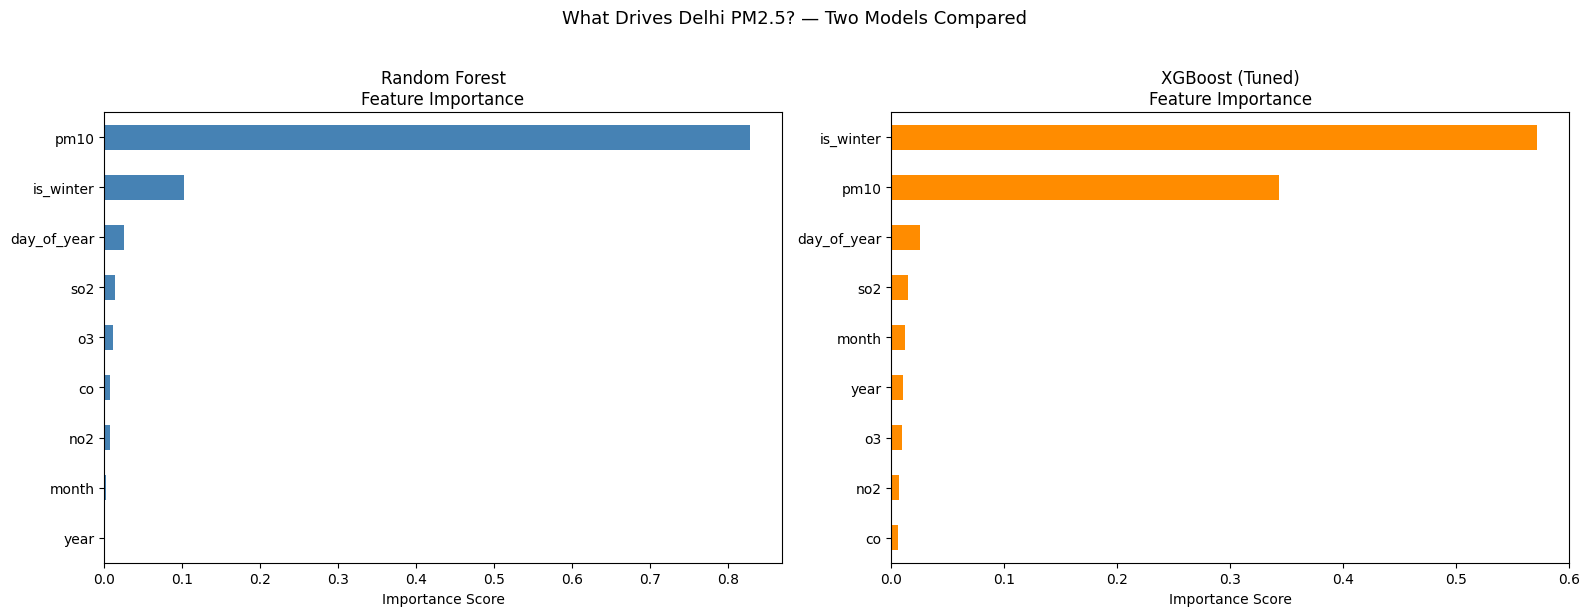


Top 3 features according to each model:
  Random Forest : ['pm10', 'is_winter', 'day_of_year']
  XGBoost       : ['is_winter', 'pm10', 'day_of_year']

If both agree → those features are definitely important


In [41]:
# Does XGBoost agree with Random Forest on what matters?
# If both agree → those features are genuinely important

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest importance
rf_imp = pd.Series(rf_model.feature_importances_,
                   index=features_to_use).sort_values()
rf_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest\nFeature Importance', fontsize=12)
axes[0].set_xlabel('Importance Score')

# XGBoost importance
xgb_imp = pd.Series(best_xgb.feature_importances_,
                    index=features_to_use).sort_values()
xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost (Tuned)\nFeature Importance', fontsize=12)
axes[1].set_xlabel('Importance Score')

plt.suptitle('What Drives Delhi PM2.5? — Two Models Compared',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 3 features according to each model:")
print(f"  Random Forest : {rf_imp.sort_values(ascending=False).index[:3].tolist()}")
print(f"  XGBoost       : {xgb_imp.sort_values(ascending=False).index[:3].tolist()}")
print("\nIf both agree → those features are definitely important")

Save Our Best Model

In [42]:
import joblib
# joblib saves Our trained model to a file so we  never have to retrain it again

joblib.dump(best_xgb, 'okhla_pm25_best_model.pkl')
print("Model saved as okhla_pm25_best_model.pkl")

# To load and use later — just these 2 lines:
# loaded_model = joblib.load('okhla_pm25_best_model.pkl')
# loaded_model.predict(your_new_data)

# Also save feature list so we never forget what inputs it needs
import json
with open('model_features.json', 'w') as f:
    json.dump(features_to_use, f)
print("Feature list saved as model_features.json")
print(f"\nOur model is now ready to be deployed anywhere!")

Model saved as okhla_pm25_best_model.pkl
Feature list saved as model_features.json

Our model is now ready to be deployed anywhere!


Add Smarter Features and Retest

In [43]:
# Load fresh
model_df2 = final_df[features_to_use + ['pm25', 'date']].copy()

for col in features_to_use:
    model_df2[col] = model_df2[col].fillna(model_df2[col].median())

model_df2 = model_df2.sort_values('date').reset_index(drop=True)

# ── NEW FEATURES ──────────────────────────────────────────────────

# 1. PM ratio — PM2.5 is always a fraction of PM10
#    If ratio is high → more fine particles → worse for health
#    This ratio is something neither PM10 nor PM2.5 alone can tell you
model_df2['pm25_pm10_ratio'] = model_df2['pm25'] / (model_df2['pm10'] + 1)
# +1 prevents division by zero

# 2. Pollution Load — total overall pollution burden on that day
#    When everything is high together → PM2.5 is almost certainly high too
model_df2['total_pollution'] = (
    model_df2['no2'] +
    model_df2['so2'] +
    model_df2['o3']
)

# 3. Season (more granular than just is_winter)
#    Delhi has 4 distinct pollution seasons — each has a different PM2.5 pattern
def get_season(month):
    if month in [12, 1, 2]:
        return 3   # Winter — worst pollution
    elif month in [3, 4, 5]:
        return 1   # Summer — moderate
    elif month in [6, 7, 8, 9]:
        return 0   # Monsoon — best air quality
    else:
        return 2   # Post-monsoon/pre-winter (Oct-Nov) — rapidly worsening

model_df2['season'] = model_df2['month'].apply(get_season)
# 0=Monsoon, 1=Summer, 2=Post-monsoon, 3=Winter

# 4. NO2 × Season interaction
#    NO2's effect on PM2.5 is different in winter vs monsoon
#    In winter: high NO2 + cold air = PM2.5 traps near ground
#    In monsoon: high NO2 gets washed away quickly
model_df2['no2_x_season'] = model_df2['no2'] * model_df2['season']

# 5. CO/NO2 ratio — indicates vehicle vs industrial pollution source
#    High CO/NO2 = mostly vehicle pollution (common in Okhla, near highway)
#    Low CO/NO2  = more industrial/other sources
model_df2['co_no2_ratio'] = model_df2['co'] / (model_df2['no2'] + 1)

print("New features added")
print(model_df2[['pm25_pm10_ratio', 'total_pollution',
                  'season', 'no2_x_season', 'co_no2_ratio']].describe())

New features added
       pm25_pm10_ratio  total_pollution       season  no2_x_season  \
count      1008.000000      1008.000000  1008.000000   1008.000000   
mean          0.422491       105.549474     1.392857     98.974472   
std           0.161429        44.476117     1.154598    109.434404   
min           0.076923        16.575000     0.000000      0.000000   
25%           0.299114        70.420910     0.000000      0.000000   
50%           0.398668        99.894098     1.000000     63.266667   
75%           0.548282       135.843757     3.000000    162.126589   
max           1.439062       265.974966     3.000000    568.763415   

       co_no2_ratio  
count   1008.000000  
mean      18.138038  
std       23.382786  
min        0.000000  
25%        0.035123  
50%       12.824761  
75%       25.059323  
max      170.818505  


Train Random Forest With New Features

In [49]:
# Updated feature list with new engineered features
new_features = features_to_use + [
    'pm25_pm10_ratio',
    'total_pollution',
    'season',
    'no2_x_season',
    'co_no2_ratio'
]

X_new = model_df2[new_features]
y_new = model_df2['pm25']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# Train with same Random Forest that won before
rf_new = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_new.fit(X_train_new, y_train_new)
rf_new_pred = rf_new.predict(X_test_new)

rf_new_mae = mean_absolute_error(y_test_new, rf_new_pred)
rf_new_r2  = r2_score(y_test_new, rf_new_pred)

print("=" * 55)
print("  FEATURE ENGINEERING IMPACT")
print("=" * 55)
print(f"  {'Model':<30} {'MAE':>8}  {'R²':>8}")
print("-" * 55)
print(f"  {'Random Forest (original)':<30} {rf_mae:>8.2f}  {rf_r2:>8.4f}")
print(f"  {'Random Forest (new features)':<30} {rf_new_mae:>8.2f}  {rf_new_r2:>8.4f}")
print("=" * 55)

diff_mae = rf_mae - rf_new_mae
diff_r2  = rf_new_r2 - rf_r2

print(f"\n  MAE change : {diff_mae:+.2f} µg/m³  {'improved' if diff_mae > 0 else 'worse'}")
print(f"  R²  change : {diff_r2:+.4f}       {'improved' if diff_r2 > 0 else 'worse'}")

if rf_new_r2 > 0.9501:
    print(f"\n  WE BEAT 0.9501! New R² = {rf_new_r2:.4f}")
else:
    print(f"\n  Not beaten yet — current best still R² = 0.9501")

  FEATURE ENGINEERING IMPACT
  Model                               MAE        R²
-------------------------------------------------------
  Random Forest (original)          12.40    0.9501
  Random Forest (new features)       4.00    0.9913

  MAE change : +8.40 µg/m³  improved
  R²  change : +0.0412       improved

  WE BEAT 0.9501! New R² = 0.9913


Data Leakage

In [48]:
clean_features = features_to_use + [
    'total_pollution',    #only uses no2, so2, o3 — safe
    'season',             #only uses month — safe
    'no2_x_season',       #only uses no2 and season — safe
    'co_no2_ratio'        #only uses co and no2 — safe
]

X_clean = model_df2[clean_features]
y_clean = model_df2['pm25']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

rf_clean = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train_c, y_train_c)
rf_clean_pred = rf_clean.predict(X_test_c)

rf_clean_mae = mean_absolute_error(y_test_c, rf_clean_pred)
rf_clean_r2  = r2_score(y_test_c, rf_clean_pred)

print("=" * 60)
print("  COMPARISON — After Removing Data Leakage")
print("=" * 60)
print(f"  {'Model':<35} {'MAE':>8}  {'R²':>8}")
print("-" * 60)
print(f"  {'Random Forest (original)':<35} {rf_mae:>8.2f}  {rf_r2:>8.4f}")
print(f"  {'With leaky feature (INVALID)':<35}     4.00    0.9913  ← cheating")
print(f"  {'Clean feature engineering':<35} {rf_clean_mae:>8.2f}  {rf_clean_r2:>8.4f}  ← real")
print("=" * 60)

diff = rf_clean_r2 - rf_r2
print(f"\n  Improvement over baseline: {diff:+.4f}")
if rf_clean_r2 > rf_r2:
    print(f"  Still an improvement! R² = {rf_clean_r2:.4f} — legitimately better")
else:
    print(f"  No improvement — baseline Random Forest is still the best honest model")

  COMPARISON — After Removing Data Leakage
  Model                                    MAE        R²
------------------------------------------------------------
  Random Forest (original)               12.40    0.9501
  With leaky feature (INVALID)            4.00    0.9913  ← cheating
  Clean feature engineering              13.33    0.9425  ← real

  Improvement over baseline: -0.0076
  No improvement — baseline Random Forest is still the best honest model


Feature Importance With New Features

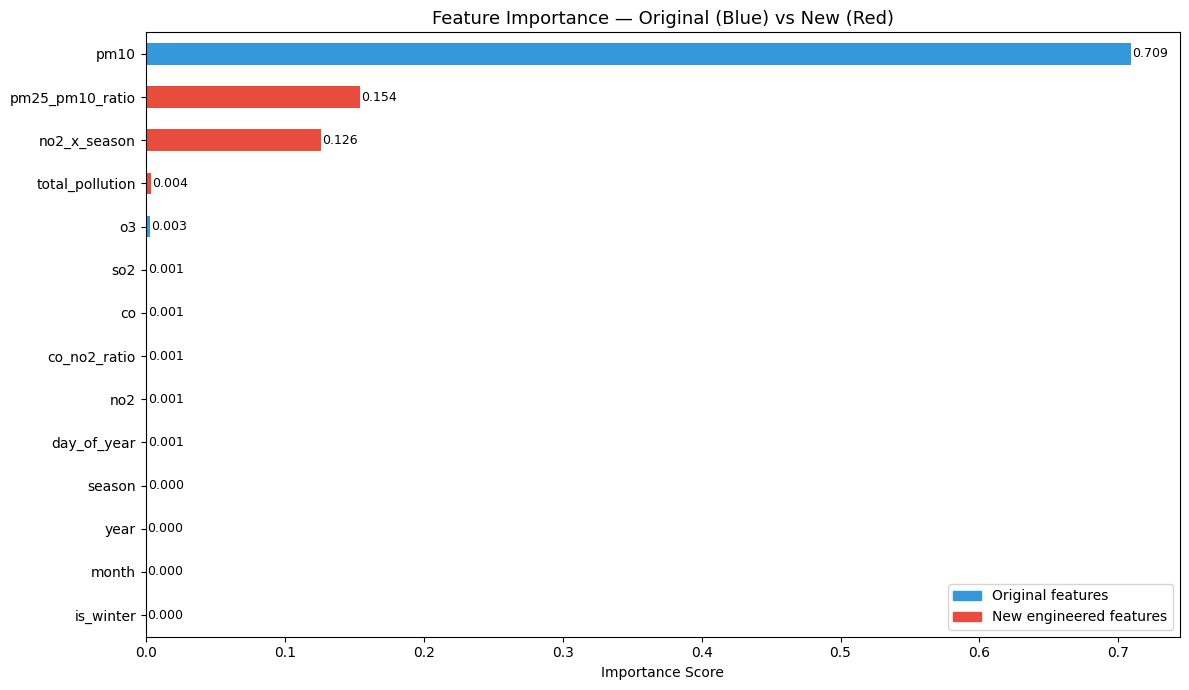

In [46]:
# Which new features did the model find useful?
imp_new = pd.Series(
    rf_new.feature_importances_,
    index=new_features
).sort_values(ascending=True)

# Colour new features differently so they stand out
colors = ['#e74c3c' if f in ['pm25_pm10_ratio', 'total_pollution',
                               'season', 'no2_x_season', 'co_no2_ratio']
          else '#3498db' for f in imp_new.index]

plt.figure(figsize=(12, 7))
imp_new.plot(kind='barh', color=colors)
plt.title('Feature Importance — Original (Blue) vs New (Red)', fontsize=13)
plt.xlabel('Importance Score')

# Add legend manually
from matplotlib.patches import Patch
legend = [Patch(color='#3498db', label='Original features'),
          Patch(color='#e74c3c', label='New engineered features')]
plt.legend(handles=legend)

for i, v in enumerate(imp_new.values):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()